In [56]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

import pandas as pd
import numpy as np

#Ploting Libraries
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
from plotnine import *
import seaborn as sns

import tqdm as notebook_tqdm

import io

#Explanation
from ciu import CIU, ciuplots

import warnings
warnings.filterwarnings('ignore')

In [40]:
X_median = pd.read_csv('data/features_imputed_median.csv').iloc[:, 1:]
X_mice = pd.read_csv('data/features_imputed_mice.csv').iloc[:, 1:]
y = pd.read_csv('data/target.csv').iloc[:, 1:]

In [41]:
def train_models(X_train, X_test, y_train, y_test, reduced=False):
        
    models = {
        'dummy_classifier': DummyClassifier(strategy='most_frequent'),
        'logistic':LogisticRegression(),
        'decision_tree': DecisionTreeClassifier(max_depth=4, max_leaf_nodes=32),
        'random_forest': RandomForestClassifier(),
        'hist_gradient_boosting':HistGradientBoostingClassifier(),
        'gradient_boosting':GradientBoostingClassifier()
    }

    model_perfomance = {}
    trained_models = {}

    for model_name in models:
        model = models[model_name]
        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)
        y_pred = np.argmax(y_proba, axis=1)
        
        model_perfomance[model_name] = {'accuracy': accuracy_score(y_test, y_pred),
                                        'f1_score': f1_score(y_test, y_pred),
                                        'recall':recall_score(y_test, y_pred),
                                        'precision':precision_score(y_test, y_pred),
                                        #'classification_report':classification_report(y_test, y_pred)
                                        }
        trained_models[model_name] = model
        
    #print(model_perfomance)
    results = pd.DataFrame(model_perfomance)
    display(results)

    return trained_models, results

In [42]:
def plot_permuted_importance(perm_imp):
    # Split top 8 vs the rest
    top8 = perm_imp.head(8)
    others = perm_imp.iloc[8:]

    # Aggregate the rest into one row
    others_row = pd.DataFrame([{
        'feature': f'All Other Features ({len(others)})',
        'importance': others['importance'].mean(),
        'std': others['std'].mean()
    }])

    # Combine and sort for plotting (smallest at top → largest at bottom for barh)
    plot_df = pd.concat([others_row, top8]).reset_index(drop=True)
    plot_df = plot_df.sort_values('importance', ascending=True)

    # Color: highlight top 8 vs the aggregated group
    colors = ['#b0b0b0'] + ['#1a6fa8'] * 8  # grey for "others", blue for top 8

    plt.figure(figsize=(10, 6))
    bars = plt.barh(
        plot_df['feature'], 
        plot_df['importance'],
        xerr=plot_df['std'],
        align='center',
        color=colors,
        edgecolor='white',
        height=0.6,
        error_kw=dict(ecolor='black', capsize=3, linewidth=0.8)
    )

    # Annotate importance values at end of each bar
    for bar, val in zip(bars, plot_df['importance']):
        plt.text(val + 0.0003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left', fontsize=8)

    plt.title('Permutation Importance (Top 8 Features)', fontsize=12)
    plt.xlabel('Mean Accuracy Decrease', fontsize=11)
    plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

In [43]:
def choose_important_features(X_test, y_test, trained_models, model_choice):
    result = permutation_importance(trained_models[model_choice], X_test, y_test, n_repeats=10, random_state=42)

    perm_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
        }).sort_values('importance', ascending=False)

    plot_permuted_importance(perm_imp)

    # Keep only features with positive importance
    important_features = perm_imp[perm_imp['importance'] > 0]['feature'].tolist()

    print(f"Kept {len(important_features)} of {X_test.shape[1]} features")

    return important_features

## Explainability

In [44]:
def get_indices(X_test, y_test):
    rng = np.random.default_rng(seed=42)

    indices_0 = np.where(y_test == 0)[0]
    indices_1 = np.where(y_test == 1)[0]

    instance_0 = X_test.iloc[[rng.choice(indices_0)]]
    instance_1 = X_test.iloc[[rng.choice(indices_1)]]

    resistant_indices = rng.choice(indices_1, 4)
    
    return resistant_indices


In [45]:
def get_ciu_results(resistant_indices, model_name, X_train, X_test, trained_models):
    model = trained_models[model_name]
    CIU_amr = CIU(model.predict_proba, ['No','Yes'], data = X_train)
    CIU_amr.instance

    ciu_results = {}
    for i in resistant_indices:
        instance_1 = X_test.iloc[[i]]
        CIUres_1 = CIU_amr.explain(instance_1, output_inds=1)
        
        #Removes the really small values, pretty much because I have in some cases 119 features
        plot_df = CIUres_1[~((CIUres_1["CI"].abs() < 1e-9) & (CIUres_1["CU"].abs() < 1e-9))] 
        ciu_results[i]=plot_df #Cleaner datagframe for plotting

    return ciu_results, CIU_amr

In [46]:
def plot_ciu_instances(ciu_results, CIU_amr):
    keys = list(ciu_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(12, 20))
    axes = axes.flatten()

    for i, key in enumerate(keys):
        result = ciu_results[key]
        
        # plot_ciu renders internally — grab the figure it just created
        CIU_amr.plot_ciu(result, plot_mode="overlap", figsize=(6, 12))
        p = plt.gcf()  # <-- capture whatever figure is currently active
        
        # Capture it to a buffer
        buf = io.BytesIO()
        p.savefig(buf, format="png", bbox_inches="tight")
        buf.seek(0)
        plt.close(p)  # close the internal figure
        
        # Paste into the subplot as an image
        img = mpimg.imread(buf)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Instance {key}")

    # Hide unused axes
    for j in range(len(keys), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(h_pad=1.0)
    plt.show()
    return

In [58]:
def plot_explain_all(CIUres):
    fig = ciuplots.ciu_beeswarm(CIUres,xcol='Cinfl',  legend_title='Value scale')
    fig.update_layout(height=600, width=900, margin=dict(l=20, r=20, t=50, b=20))
    fig.update_layout(
        title='CInfl versus input value for all features',
        xaxis=dict(title='Contextual Influence (CInf)'),
        yaxis=dict(title='Feature'),
    )
    fig.show()


    fig = ciuplots.ciu_beeswarm(CIUres,  legend_title='Value scale')
    fig.update_layout(height=600, width=900, margin=dict(l=20, r=20, t=50, b=20))
    fig.update_layout(
        title='CI versus input value for all features',
        xaxis=dict(title='Contextual Importance (CI)'),
        yaxis=dict(title='Feature'),
    )
    fig.show()

    fig = ciuplots.ciu_beeswarm(CIUres, xcol='CU', legend_title='Value scale')
    fig.update_layout(height=600, width=900, margin=dict(l=20, r=20, t=20, b=20), 
                      xaxis=dict(title='Contextual Utility (CU)'))
    fig.show()


## Putting Everything together

In [60]:
def feature_selection_train_pipeline(X, y, reduced=False, explain_all=False):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    trained_models, results = train_models(X_train, X_test, y_train, y_test, reduced=False)
    
    if not reduced:
        resistant_indices = get_indices(X_test, y_test)
        ciu_results, CIU_amr = get_ciu_results(resistant_indices, 'gradient_boosting', X_train, X_test, trained_models)
        plot_ciu_instances(ciu_results, CIU_amr)
        
        if explain_all:
            CIUres = CIU_amr.explain_all(X_test, output_inds=1, do_norm_invals=True)
            plot_explain_all(CIUres)
            CIUres.to_csv('data/ciu_score.csv')

        return X,trained_models, results

    important_features = choose_important_features(X_test, y_test, trained_models, 'gradient_boosting')

    return X[important_features], trained_models, results

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.665917,0.662667,0.685500,0.686833,0.681500
f1_score,0.00000,0.619459,0.658857,0.680981,0.680061,0.676102
recall,0.00000,0.543562,0.651174,0.670998,0.665334,0.664501
precision,0.00000,0.719991,0.666724,0.691265,0.695455,0.688115


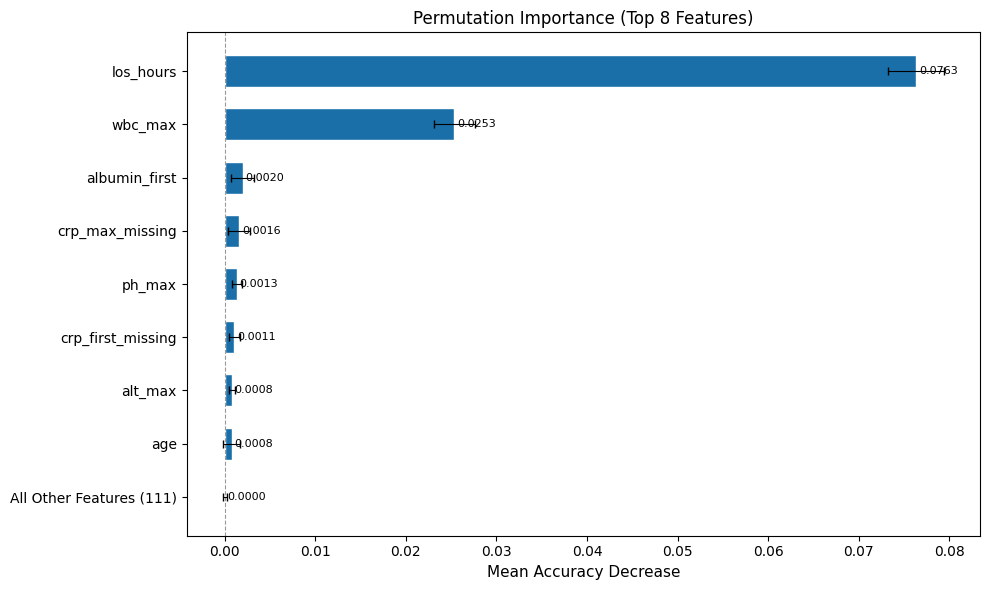

Kept 48 of 119 features


In [48]:
X_reduced, trained_models, results = feature_selection_train_pipeline(X_median, y, True)

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.664000,0.662667,0.679667,0.685250,0.681333
f1_score,0.00000,0.619335,0.658857,0.674568,0.677813,0.674664
recall,0.00000,0.546393,0.651174,0.663668,0.661836,0.660503
precision,0.00000,0.714753,0.666724,0.685832,0.694580,0.689445


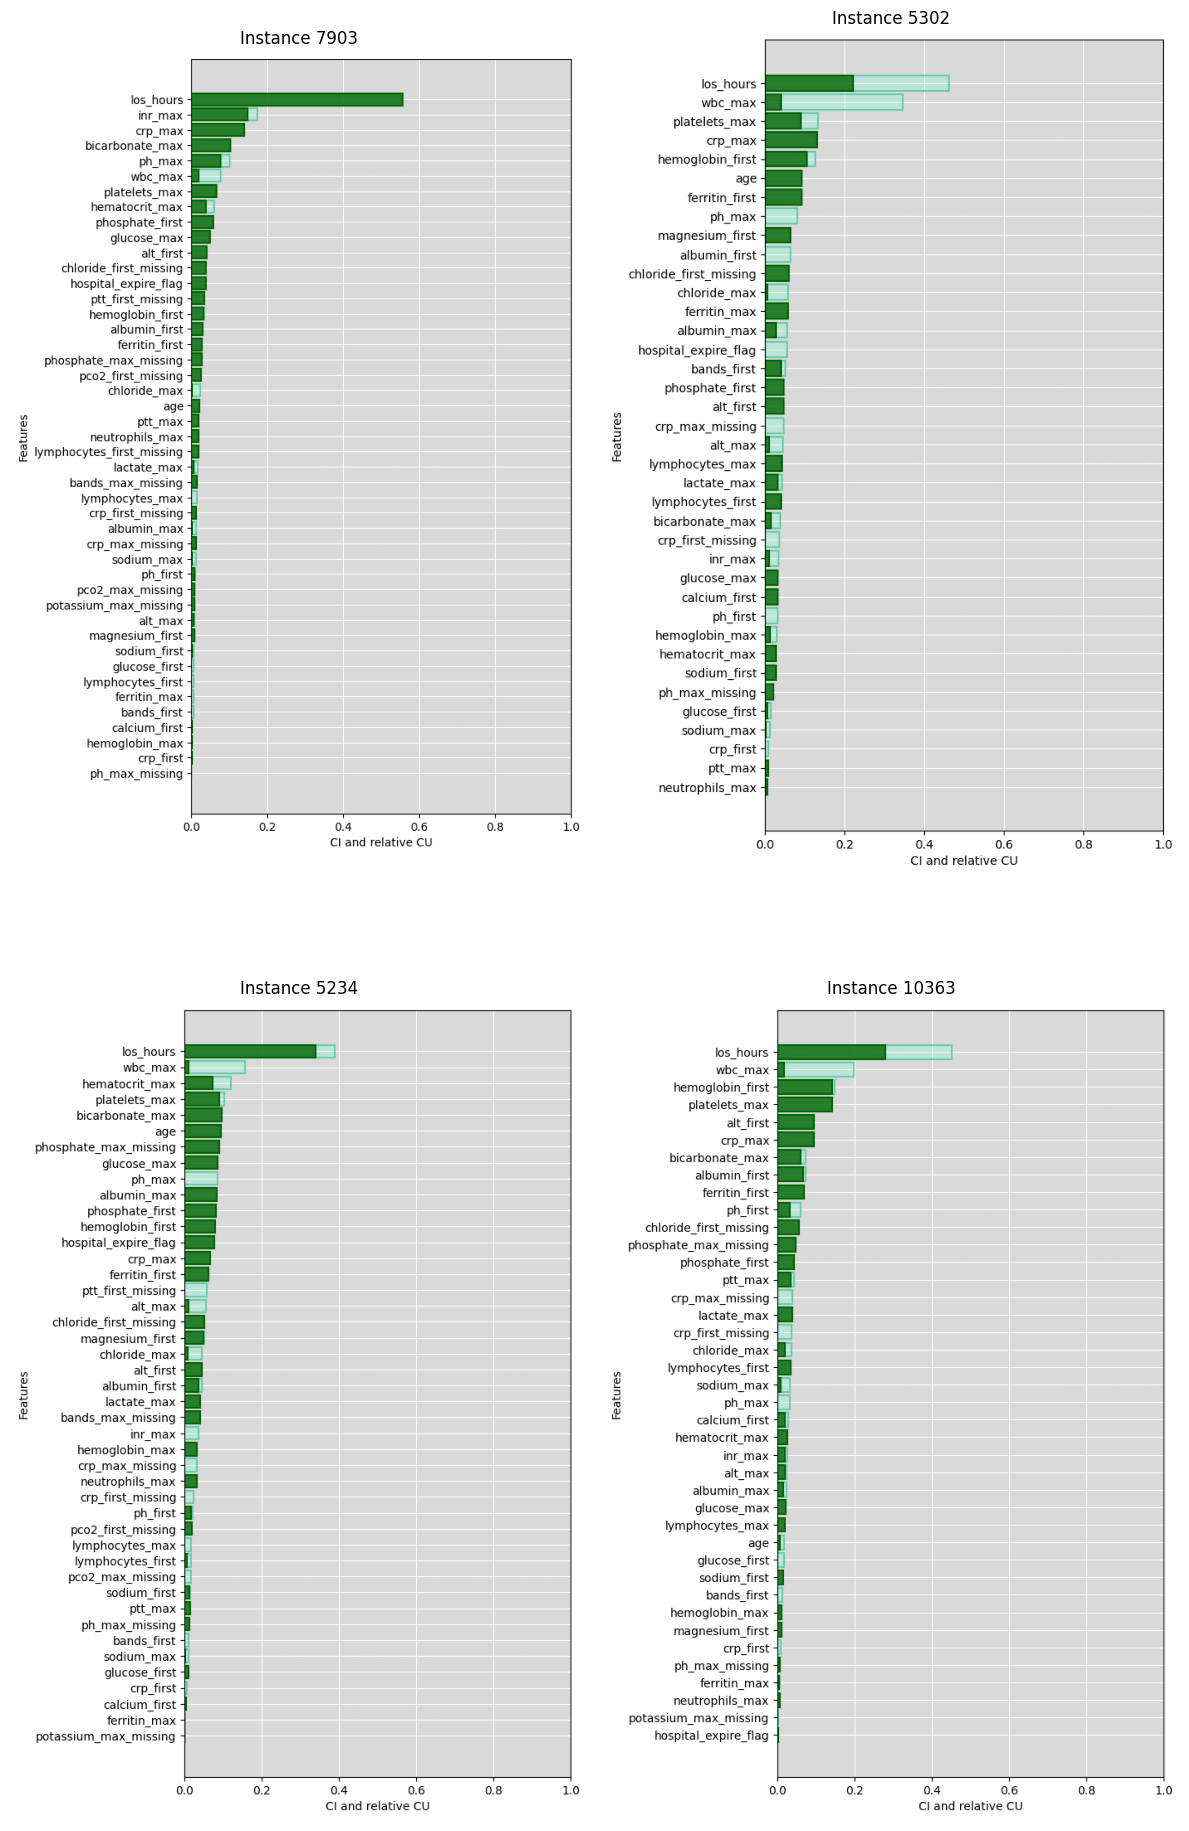

In [49]:
X_reduced, trained_models, results = feature_selection_train_pipeline(X_reduced, y, False)

In [50]:
# Removing Length of Stay (LOS)
X_reduced_los_dropped = X_reduced.drop(columns='los_hours')

,dummy_classifier,logistic,decision_tree,random_forest,hist_gradient_boosting,gradient_boosting
accuracy,0.49975,0.634000,0.636333,0.665083,0.672833,0.668583
f1_score,0.00000,0.593409,0.600000,0.660242,0.666043,0.655999
recall,0.00000,0.533900,0.545227,0.650508,0.652174,0.631684
precision,0.00000,0.667847,0.667006,0.670271,0.680515,0.682260


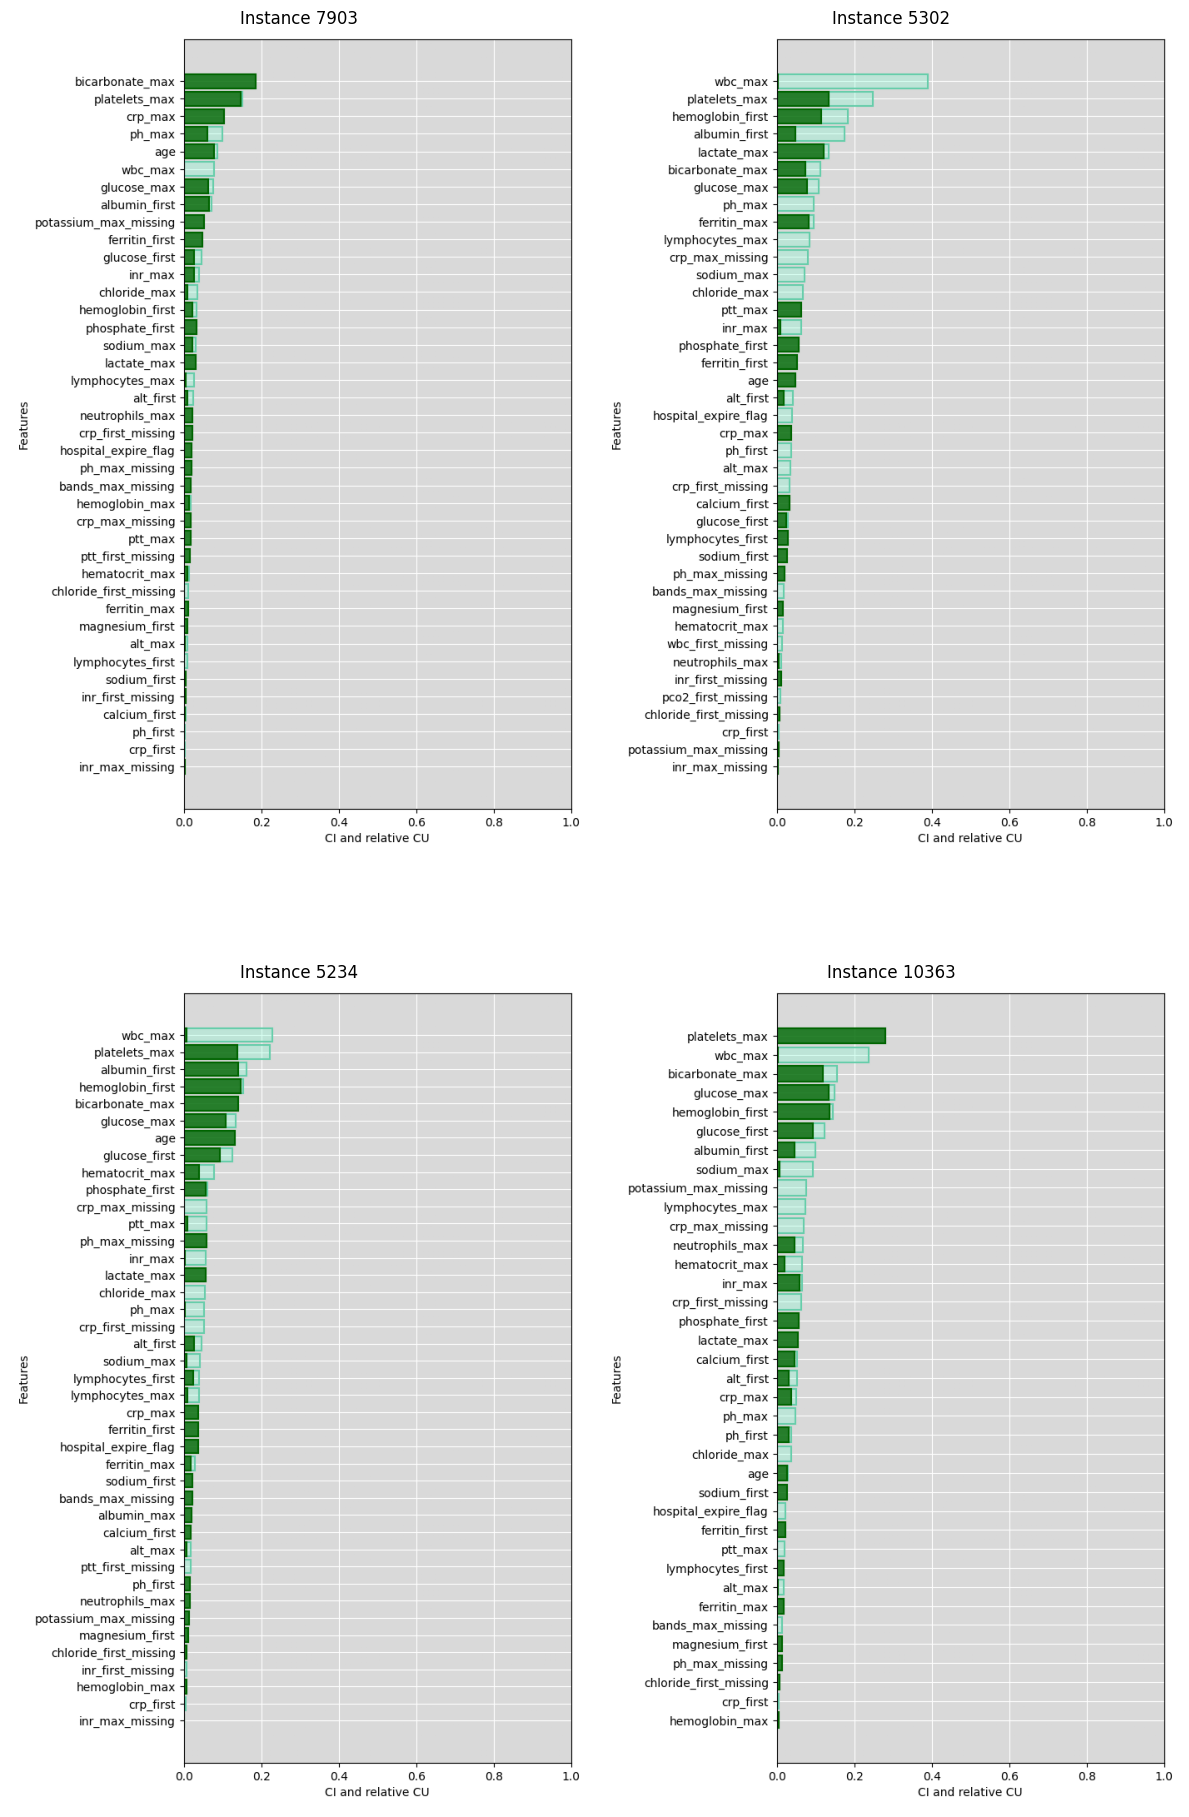

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [61]:
X_reduced_los_dropped, trained_models, results = feature_selection_train_pipeline(X_reduced_los_dropped, y, False, explain_all=True)

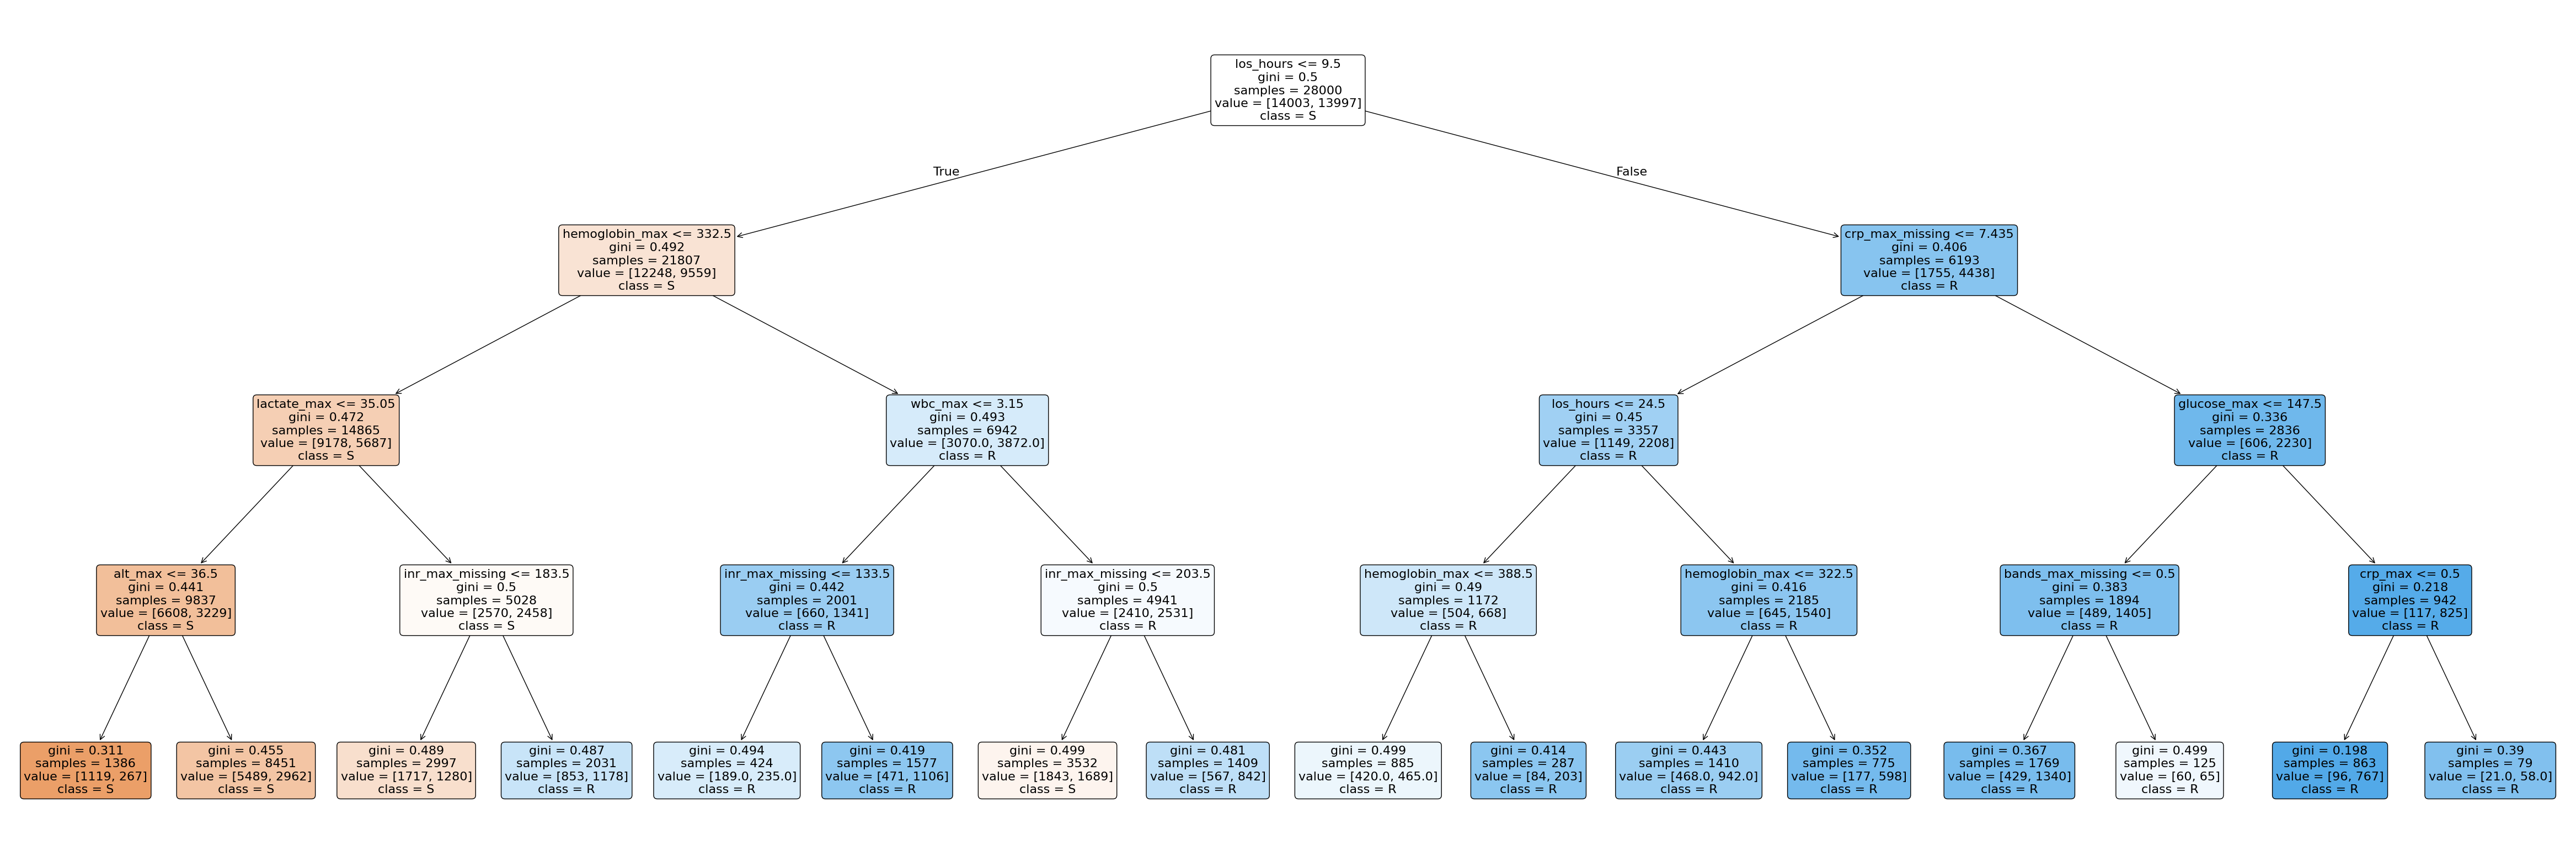

In [52]:
def plot_tree_from_output():
    fig, ax = plt.subplots(figsize=(60, 20))
    plot_tree(
        trained_models['decision_tree'],       # your fitted DecisionTreeClassifier
        feature_names=X_reduced.columns.tolist(),
        class_names=['S', 'R'],
        filled=True,                    # colour nodes by class
        rounded=True,
        fontsize=16,
        ax=ax
    )
    plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_tree_from_output()

In [53]:
results = results.T

In [54]:
print(results.classification_report.loc['gradient_boosting'])

AttributeError: 'DataFrame' object has no attribute 'classification_report'